Recomendador de plataforma
Una empresa de desarrollo de software desea construir un sistema inteligente que recomiende la plataforma más adecuada (web, mobile o desktop) para nuevos proyectos, en base a las características del proyecto y la experiencia previa con proyectos similares.



✅ Objetivo

Implementa un sistema en Python utilizando clases, estructuras de datos y machine learning (árbol de decisión) que sea capaz de predecir la mejor plataforma para un nuevo proyecto.



🧱 Parte 1: Modelar los proyectos

Crea una clase llamada Project con los siguientes atributos:

name: nombre del proyecto (str)

team_size: tamaño del equipo de desarrollo (int)

budget: presupuesto en miles de dólares (float)

duration_months: duración estimada en meses (int)

realtime_required: si requiere tiempo real (bool)

needs_offline: si necesita funcionar sin conexión (bool)

target_users: tipo de usuarios objetivo (str): puede ser "local", "empresa" o "global"

recommended_platform: plataforma recomendada (str): puede ser "web", "mobile" o "desktop"

⚠️ Este último atributo (recommended_platform) solo debe tener valor en proyectos históricos. En los nuevos proyectos (aquellos para los que se desea predecir la plataforma), este atributo debe estar en None.

🔧 Método to_features()

Implementa un método llamado to_features(self, label_encoder=None) que convierta un proyecto a una lista de características numéricas, útil para entrenar o hacer predicciones.

✔️ Este método debe convertir realtime_required y needs_offline en 0 o 1, y codificar el atributo target_users con un LabelEncoder.



📊 Parte 2: Construir el dataset

Crea una clase llamada ProjectDataset que reciba una lista de proyectos (históricos y nuevos) y tenga:

Métodos:

_fit_encoders(): crea y entrena internamente dos LabelEncoder: uno para target_users y otro para recommended_platform.

get_X_y(): devuelve dos listas:

X: la matriz de características de los proyectos históricos

y: las plataformas codificadas de los proyectos históricos

decode_platform(label): transforma una predicción numérica a su plataforma original (str)

✔️ Usa LabelEncoder para convertir texto a números y viceversa.





🧠 Parte 3: Entrenar el modelo

Crea una clase llamada PlatformRecommender que:

Use un modelo de DecisionTreeClassifier de scikit-learn.

Tenga dos métodos:

train(dataset: ProjectDataset): entrena el modelo con los datos históricos.

predict(project: Project): predice la plataforma más adecuada para un nuevo proyecto, devolviendo "web", "mobile" o "desktop".

⚠️ Importante: Antes de usar predict(), debes haber llamado a train().



🧪 Parte 4: Prueba tu sistema

Usa los siguientes datos de proyectos históricos:

projects = [

    Project("AppGlobal", 5, 25.0, 6, True, False, "global", "web"),
    
    Project("IntranetCorp", 10, 40.0, 12, False, True, "empresa", "desktop"),
    
    Project("LocalDelivery", 3, 20.0, 4, True, True, "local", "mobile"),
    
    Project("CloudDashboard", 6, 50.0, 8, True, False, "empresa", "web"),
    
    Project("OfflineTool", 4, 15.0, 6, False, True, "local", "desktop"),
    
    Project("SocialBuzz", 2, 10.0, 3, True, False, "global", "mobile"),
    
]
Y predice la plataforma recomendada para este nuevo proyecto:

new_project = Project("AIChatApp", 4, 30.0, 5, True, False, "global")


🌳 Parte 5: Visualiza el árbol de decisión

Crea una clase llamada PlatformRecommenderVisualizer que tenga un método plot_tree() que reciba un objeto PlatformRecommender y genere un gráfico del árbol de decisión.

📌 Puedes usar el siguiente código:

plt.figure(figsize=(12, 6))

tree.plot_tree(

    model,
    
    feature_names=["team_size", "budget", "duration_months", "realtime_required", "needs_offline", "target_users"],
    
    class_names=model_classes,
    
    filled=True,
    
    rounded=True
    
)

plt.show()


🧪 Ejemplo de uso

projects = [
    Project("AppGlobal", 5, 25.0, 6, True, False, "global", "web"),
    
    Project("IntranetCorp", 10, 40.0, 12, False, True, "empresa", "desktop"),
    
    Project("LocalDelivery", 3, 20.0, 4, True, True, "local", "mobile"),
    
    Project("CloudDashboard", 6, 50.0, 8, True, False, "empresa", "web"),
    
    Project("OfflineTool", 4, 15.0, 6, False, True, "local", "desktop"),
    
    Project("SocialBuzz", 2, 10.0, 3, True, False, "global", "mobile"),
]
 
# Nuevo proyecto a predecir

new_project = Project("AIChatApp", 4, 30.0, 5, True, False, "global")
 
# Entrenamiento y predicción

dataset = ProjectDataset(projects)

recommender = PlatformRecommender()

recommender.train(dataset)

 
prediction = recommender.predict(new_project)

print(f"Plataforma recomendada para '{new_project.name}': {prediction}")
 
# Visualización del árbol

visualizer = PlatformRecommenderVisualizer()

visualizer.plot_tree(recommender)


🧪 Salida esperada

Plataforma recomendada para 'AIChatApp': web






Practicar con los arboles de decisión en python

# Solucion:

✅ Modelo entrenado con 6 proyectos históricos.
🚀 Plataforma recomendada para 'AIChatApp': MOBILE


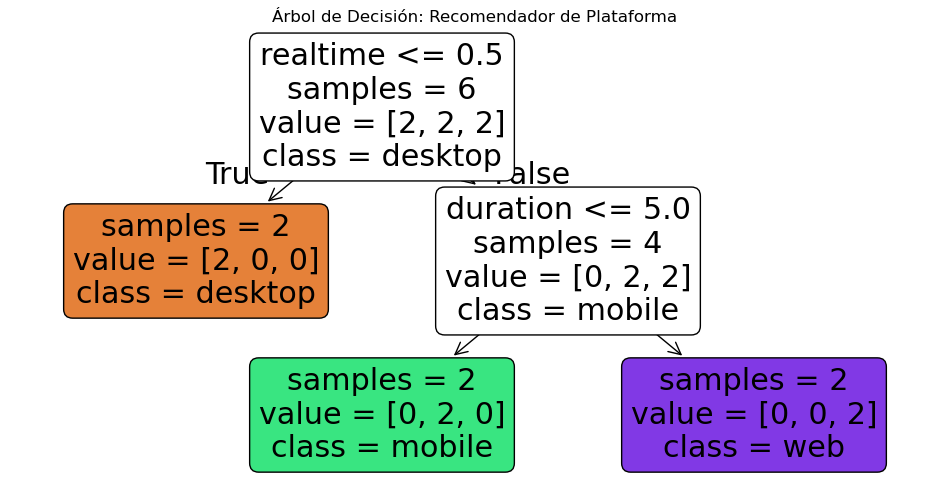

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder


class Project:
    def __init__(self, name, team_size, budget, duration_months, realtime_required, needs_offline, target_users, recommended_platform=None):
        self.name = name
        self.team_size = team_size
        self.budget = budget
        self.duration_months = duration_months
        self.realtime_required = realtime_required
        self.needs_offline = needs_offline
        self.target_users = target_users
        self.recommended_platform = recommended_platform

    def to_features(self, label_encoder=None):
        
        
        realtime_val = 1 if self.realtime_required else 0
        offline_val = 1 if self.needs_offline else 0
        
        
        if label_encoder:
            
            user_val = label_encoder.transform([self.target_users])[0]
        else:
            user_val = 0 

        return [self.team_size, self.budget, self.duration_months, realtime_val, offline_val, user_val]

    def __repr__(self):
        return f"Project({self.name})"



class ProjectDataset:
    def __init__(self, projects):
        self.projects = projects
        self.user_encoder = LabelEncoder()
        self.platform_encoder = LabelEncoder()
        self._fit_encoders()

    def _fit_encoders(self):
        
        all_users = [p.target_users for p in self.projects]
        self.user_encoder.fit(all_users)
        
        
        valid_platforms = [p.recommended_platform for p in self.projects if p.recommended_platform is not None]
        self.platform_encoder.fit(valid_platforms)

    def get_X_y(self):
        X = []
        y = []
        for p in self.projects:
            
            if p.recommended_platform is not None:
                X.append(p.to_features(self.user_encoder))
                
                y.append(self.platform_encoder.transform([p.recommended_platform])[0])
        return X, y

    def decode_platform(self, label_id):
        
        return self.platform_encoder.inverse_transform([label_id])[0]



class PlatformRecommender:
    def __init__(self):
        self.model = DecisionTreeClassifier(random_state=42, max_depth=5)
        self.dataset_ref = None 

    def train(self, dataset: ProjectDataset):
        self.dataset_ref = dataset 
        X, y = dataset.get_X_y()
        self.model.fit(X, y)
        print(f"✅ Modelo entrenado con {len(X)} proyectos históricos.")

    def predict(self, project: Project):
        if not self.dataset_ref:
            raise Exception("El modelo debe ser entrenado antes de predecir.")
        
        
        features = project.to_features(self.dataset_ref.user_encoder)
        
        
        prediction_id = self.model.predict([features])[0]
        
        
        return self.dataset_ref.decode_platform(prediction_id)



class PlatformRecommenderVisualizer:
    def plot_tree(self, recommender):
        if not recommender.model:
            return
        
        plt.figure(figsize=(12, 6))
        
        class_names = recommender.dataset_ref.platform_encoder.classes_
        
        plot_tree(
            recommender.model,
            feature_names=["team_size", "budget", "duration", "realtime", "offline", "users"],
            class_names=class_names,
            filled=True,
            rounded=True,
            impurity=False
        )
        plt.title("Árbol de Decisión: Recomendador de Plataforma")
        plt.show()



if __name__ == "__main__":
    
    projects = [
        Project("AppGlobal", 5, 25.0, 6, True, False, "global", "web"),
        Project("IntranetCorp", 10, 40.0, 12, False, True, "empresa", "desktop"),
        Project("LocalDelivery", 3, 20.0, 4, True, True, "local", "mobile"),
        Project("CloudDashboard", 6, 50.0, 8, True, False, "empresa", "web"),
        Project("OfflineTool", 4, 15.0, 6, False, True, "local", "desktop"),
        Project("SocialBuzz", 2, 10.0, 3, True, False, "global", "mobile"),
    ]

    
    dataset = ProjectDataset(projects)

    
    recommender = PlatformRecommender()
    recommender.train(dataset)

    
    new_project = Project("AIChatApp", 4, 30.0, 5, True, False, "global")

    
    prediction = recommender.predict(new_project)
    print(f"🚀 Plataforma recomendada para '{new_project.name}': {prediction.upper()}")

    
    viz = PlatformRecommenderVisualizer()
    viz.plot_tree(recommender)

Casos de prueba

Suspenso: O, Aprobado: 3 de 3 pruebas

test_different_input

test_predict_platform_type

test_prediction_is_string
